# 1. Exploratory Data Analysis (EDA)

**Objective**: To characterize the dataset, identify quality issues, and understand the underlying distributions before any processing. This analysis informs **Section 2 of the Report**.

**Outputs**:
- `missing_values_heatmap.png`
- `category_distribution.png`
- `correlation_matrix.png`

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from app.src import config

# Setup Aesthetics
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
SAVE_DIR = config.RESULTS_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

# Load Raw Data
df = pd.read_csv(config.RAW_DATA_PATH, low_memory=False)
print(f"Dataset Loaded: {df.shape}")

Dataset Loaded: (188954, 43)


## 1.1 Data Quality: Missing Values
Visualizing the sparsity of the dataset to justify imputation strategies.

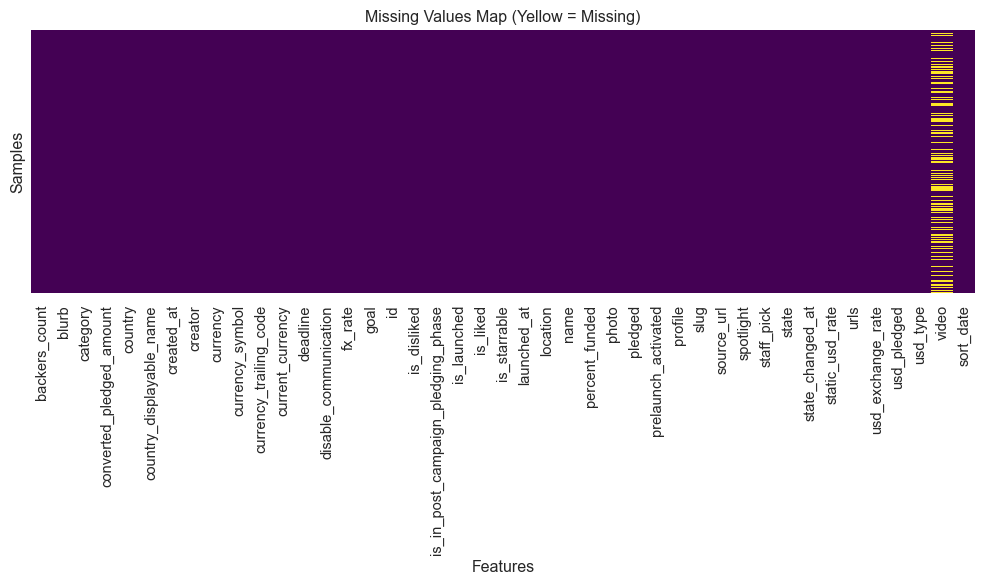

In [2]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Map (Yellow = Missing)')
plt.xlabel('Features')
plt.ylabel('Samples')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'missing_values_heatmap.png'), dpi=300)
plt.show()

## 1.2 Categorical Analysis: Project Categories
Examining the diversity of projects. Are some categories dominant?

C:\Users\aless\AppData\Local\Temp\ipykernel_12944\2908052935.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, palette='mako')
C:\Users\aless\AppData\Local\Temp\ipykernel_12944\2908052935.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


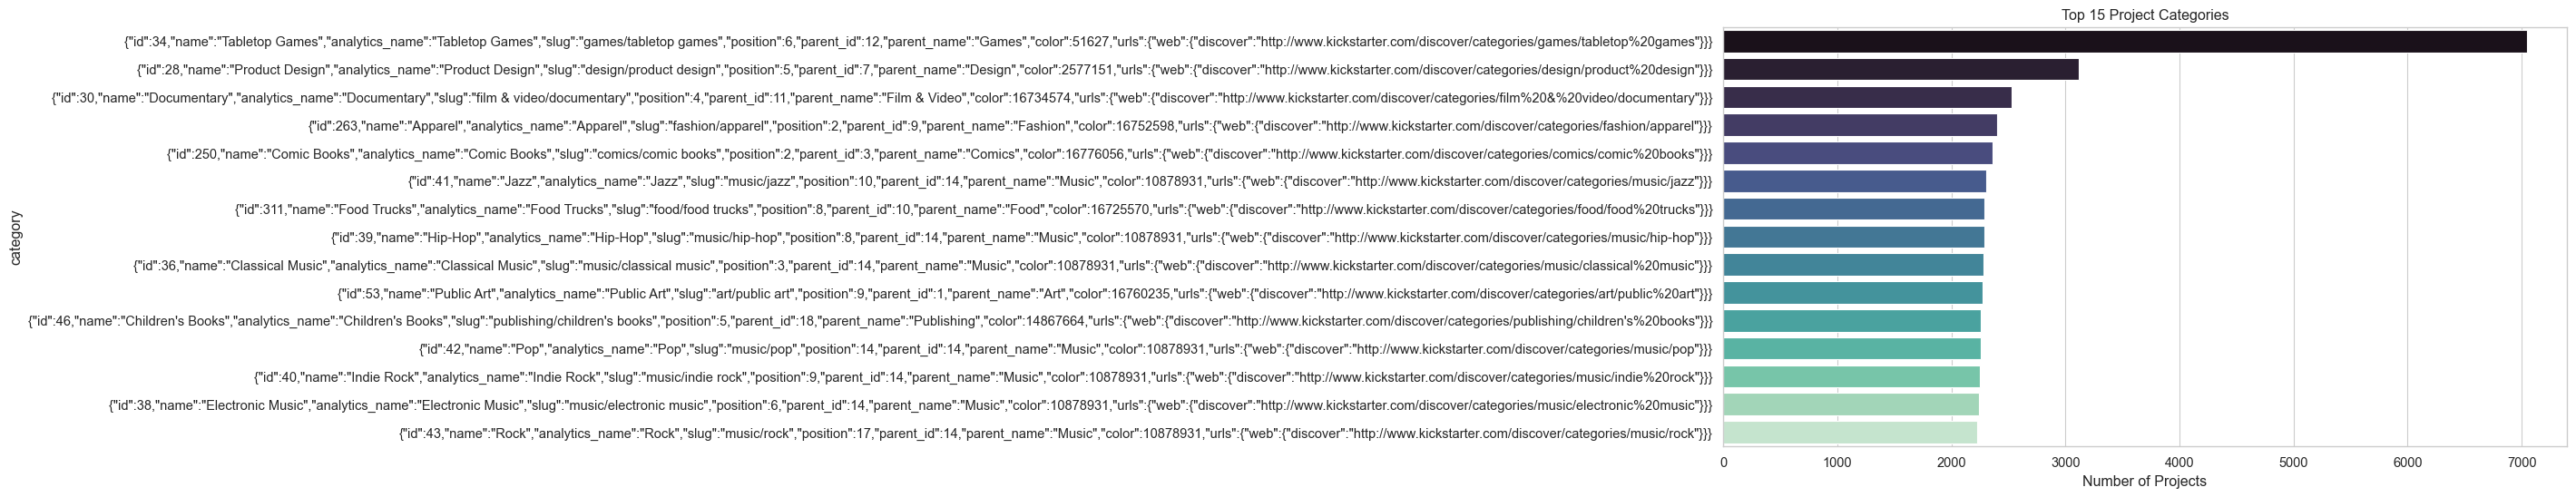

In [3]:
# Parse Category JSON if needed, or use a simplified column if available.
# Assuming 'category' column might need parsing or there's a 'category_slug'
# For raw data visualization, we might look at a 'slug' or 'parent_id' if available.
# If raw 'category' is a string representative:
top_cats = df['category'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_cats.values, y=top_cats.index, palette='mako')
plt.title('Top 15 Project Categories')
plt.xlabel('Number of Projects')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'category_distribution.png'), dpi=300)
plt.show()

## 1.3 Numerical Correlation Analysis
Checking interactions between numerical features like `goal`, `backers_count` (if present), and others.

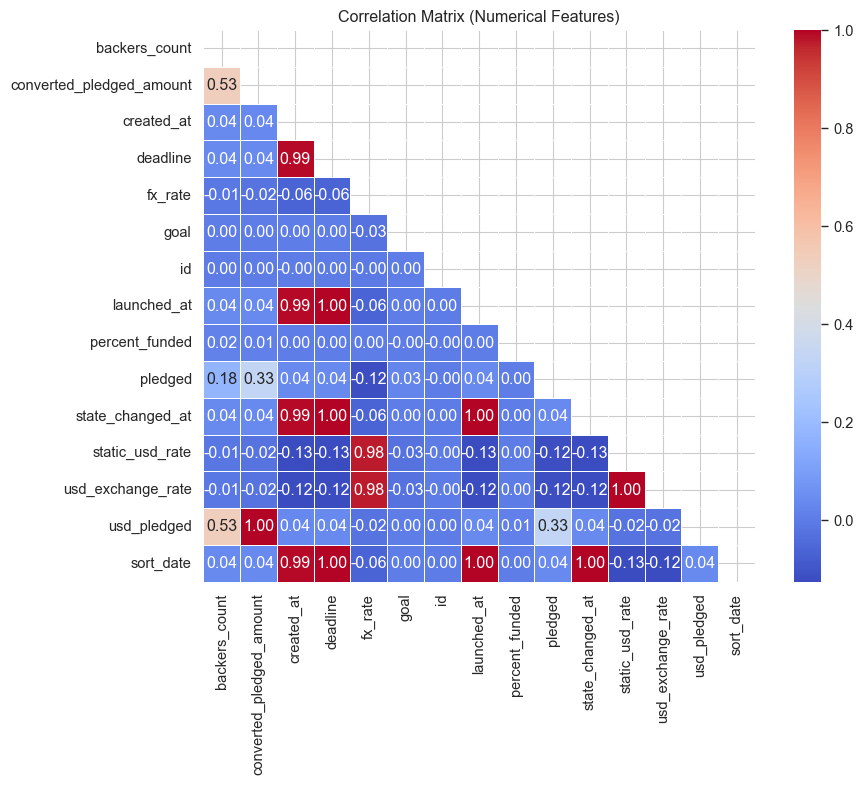

In [4]:
# Select only numerical columns
num_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10, 8))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Matrix (Numerical Features)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'correlation_matrix.png'), dpi=300)
plt.show()